### SENTINEL — Classical Lane Detection Pipeline\n\n**Notebook 02** — HSV preprocessing, Canny edge detection, Hough line transform,\nHOG feature extraction, and SVM lane classification.\n\nConsumes `processed/labels_train.json` and `processed/labels_test.json` from Notebook 01.

---\n## Cell 1 — Imports, config, and data loading

In [9]:
import json
import random
import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)
from skimage.feature import hog

# ── Constants (must match notebook 01) ────────────────────────
IMG_W, IMG_H = 320, 180
LOOKAHEAD_PX = 45
MIN_POLY_PTS = 5
SEED = 42
PROCESSED_DIR = Path("processed")

# ── Poly helpers (same as notebook 01) ────────────────────────
def poly_x(coeffs, y):
    a, b, c = coeffs
    return a * y**2 + b * y + c

def fit_poly(pts):
    ys = np.array([p[1] for p in pts], dtype=np.float64)
    xs = np.array([p[0] for p in pts], dtype=np.float64)
    return np.polyfit(ys, xs, 2).tolist()

def avg_poly(left, right):
    return [(l + r) / 2.0 for l, r in zip(left, right)]

def steering_error(mid_poly):
    y_la = IMG_H - LOOKAHEAD_PX
    return float(poly_x(mid_poly, y_la) - IMG_W / 2.0)

# ── Load splits ───────────────────────────────────────────────
with open(PROCESSED_DIR / "labels_train.json", "r", encoding="utf-8") as f:
    train_labels = json.load(f)
with open(PROCESSED_DIR / "labels_test.json", "r", encoding="utf-8") as f:
    test_labels = json.load(f)

print(f"Train: {len(train_labels)} samples")
print(f"Test:  {len(test_labels)} samples")
print(f"Train has_lane: {sum(1 for l in train_labels if l['has_lane'])} / "
      f"{sum(1 for l in train_labels if not l['has_lane'])} no-lane")
print(f"Test  has_lane: {sum(1 for l in test_labels if l['has_lane'])} / "
      f"{sum(1 for l in test_labels if not l['has_lane'])} no-lane")

Train: 2538 samples
Test:  545 samples
Train has_lane: 2538 / 0 no-lane
Test  has_lane: 545 / 0 no-lane


---\n## Cell 2 — Why HSV over RGB?\n\n### Colour space justification\n\nWe convert input images from BGR to **HSV** (Hue, Saturation, Value) before\nthresholding for lane markings. This is superior to operating directly in RGB\nfor lane detection because:\n\n1. **Luminance/chrominance separation.** In HSV, the V (value) channel captures\n   brightness independently of colour. Road scenes have dramatic lighting\n   variation (shadows, overexposure, time-of-day changes). In RGB, a shadow\n   shifts all three channels simultaneously, making fixed thresholds fragile.\n   In HSV, we can threshold on H and S while tolerating V variation.\n\n2. **Intuitive lane colour modelling.** Lane markings are either **white**\n   (low S, high V in HSV) or **yellow** (narrow H band ~18-30, moderate S, high V).\n   In RGB, white is (high R, high G, high B) and yellow is (high R, high G, low B)\n   — these overlap in individual channels and require complex multi-channel logic.\n   In HSV, a single `inRange` per colour suffices.\n\n3. **Robustness to illumination.** Empirical studies (Chiu & Lin, 2005;\n   Hillel et al., 2014) consistently show HSV-based lane detectors outperform\n   RGB-based ones under varying lighting, particularly for white lane markings\n   on grey asphalt where RGB contrast is low.\n\n**Grayscale** loses colour information entirely, making it impossible to\ndistinguish yellow lanes from bright pavement. We evaluate all three colour\nspaces in Experiment 1 (notebook 05).

---\n## Cell 3 — Classical pipeline functions\n\nFull pipeline: BGR -> HSV threshold -> Canny -> ROI mask -> Hough lines ->\ngroup by slope -> fit polynomial -> midline -> steering error.

In [10]:
# ── HSV thresholding ──────────────────────────────────────────

def hsv_threshold(img_bgr):
    """Threshold for white and yellow lane markings in HSV space.

    Returns a binary mask (255 = lane candidate pixel).
    """
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # White lanes: low saturation, high value
    white_lo = np.array([0, 0, 180], dtype=np.uint8)
    white_hi = np.array([180, 60, 255], dtype=np.uint8)
    white_mask = cv2.inRange(hsv, white_lo, white_hi)

    # Yellow lanes: narrow hue band, moderate saturation, high value
    yellow_lo = np.array([15, 60, 120], dtype=np.uint8)
    yellow_hi = np.array([35, 255, 255], dtype=np.uint8)
    yellow_mask = cv2.inRange(hsv, yellow_lo, yellow_hi)

    return cv2.bitwise_or(white_mask, yellow_mask)


# ── Canny edge detection ─────────────────────────────────────

def canny_edges(mask, low=50, high=150):
    """Apply Gaussian blur then Canny to a binary mask."""
    blurred = cv2.GaussianBlur(mask, (5, 5), 0)
    return cv2.Canny(blurred, low, high)


# ── Region of interest ───────────────────────────────────────

def roi_mask(edges):
    """Apply a trapezoidal ROI covering the lower 60% of the image.

    The trapezoid narrows toward the horizon to match perspective.
    """
    h, w = edges.shape
    y_top = int(h * 0.40)  # top of ROI = 40% from top

    vertices = np.array([[
        (0,         h),           # bottom-left
        (w * 0.35,  y_top),      # top-left
        (w * 0.65,  y_top),      # top-right
        (w,         h),           # bottom-right
    ]], dtype=np.int32)

    mask = np.zeros_like(edges)
    cv2.fillPoly(mask, vertices, 255)
    return cv2.bitwise_and(edges, mask)


# ── Hough line transform ─────────────────────────────────────

def hough_lines(edges, rho=1, theta=np.pi/180, threshold=20,
                min_line_len=20, max_line_gap=15):
    """Detect line segments via probabilistic Hough transform."""
    lines = cv2.HoughLinesP(edges, rho, theta, threshold,
                            minLineLength=min_line_len,
                            maxLineGap=max_line_gap)
    if lines is None:
        return []
    return lines.reshape(-1, 4)  # each row: [x1, y1, x2, y2]


# ── Group lines by slope ─────────────────────────────────────

def group_lines(lines):
    """Separate line segments into left-lane and right-lane groups by slope.

    Left lane: negative slope (line goes from bottom-left to upper-right
               in image coords where y increases downward).
    Right lane: positive slope.

    Filter out near-horizontal lines (|slope| < 0.3).
    """
    left_pts = []
    right_pts = []

    for x1, y1, x2, y2 in lines:
        dx = x2 - x1
        if dx == 0:
            continue
        slope = (y2 - y1) / dx

        if abs(slope) < 0.3:
            continue  # near-horizontal, ignore

        if slope < 0:
            # Negative slope = left lane
            left_pts.append([float(x1), float(y1)])
            left_pts.append([float(x2), float(y2)])
        else:
            # Positive slope = right lane
            right_pts.append([float(x1), float(y1)])
            right_pts.append([float(x2), float(y2)])

    return left_pts, right_pts


# ── Full classical pipeline ──────────────────────────────────

def classical_pipeline(img_bgr):
    """Run full classical lane detection on a single BGR image.

    Returns dict with:
      - has_lane: bool
      - left_poly, right_poly, mid_poly: [a,b,c] or None
      - steering_error: float or None
      - lane_width_px: float or None
      - intermediates: dict of debug images
    """
    # Step 1: HSV threshold
    mask = hsv_threshold(img_bgr)

    # Step 2: Canny edges
    edges = canny_edges(mask)

    # Step 3: ROI mask
    roi = roi_mask(edges)

    # Step 4: Hough lines
    lines = hough_lines(roi)

    intermediates = {
        "hsv_mask": mask,
        "canny": edges,
        "roi": roi,
        "hough_lines": lines,
    }

    if len(lines) == 0:
        return {
            "has_lane": False,
            "left_poly": None, "right_poly": None,
            "mid_poly": None, "steering_error": None,
            "lane_width_px": None,
            "intermediates": intermediates,
        }

    # Step 5: Group by slope
    left_pts, right_pts = group_lines(lines)

    # Need enough points on each side to fit a polynomial
    if len(left_pts) < MIN_POLY_PTS or len(right_pts) < MIN_POLY_PTS:
        return {
            "has_lane": False,
            "left_poly": None, "right_poly": None,
            "mid_poly": None, "steering_error": None,
            "lane_width_px": None,
            "intermediates": intermediates,
        }

    # Step 6: Fit polynomials
    left_poly = fit_poly(left_pts)
    right_poly = fit_poly(right_pts)
    mid_poly = avg_poly(left_poly, right_poly)
    err = steering_error(mid_poly)

    # Lane width at bottom
    y_bot = float(IMG_H - 1)
    lane_w = abs(poly_x(right_poly, y_bot) - poly_x(left_poly, y_bot))

    return {
        "has_lane": True,
        "left_poly": left_poly,
        "right_poly": right_poly,
        "mid_poly": mid_poly,
        "steering_error": err,
        "lane_width_px": lane_w,
        "intermediates": intermediates,
    }


print("Classical pipeline functions defined")

Classical pipeline functions defined


---\n## Cell 4 — Pipeline visualisation\n\nRun on 6 sample images and show all intermediate stages.

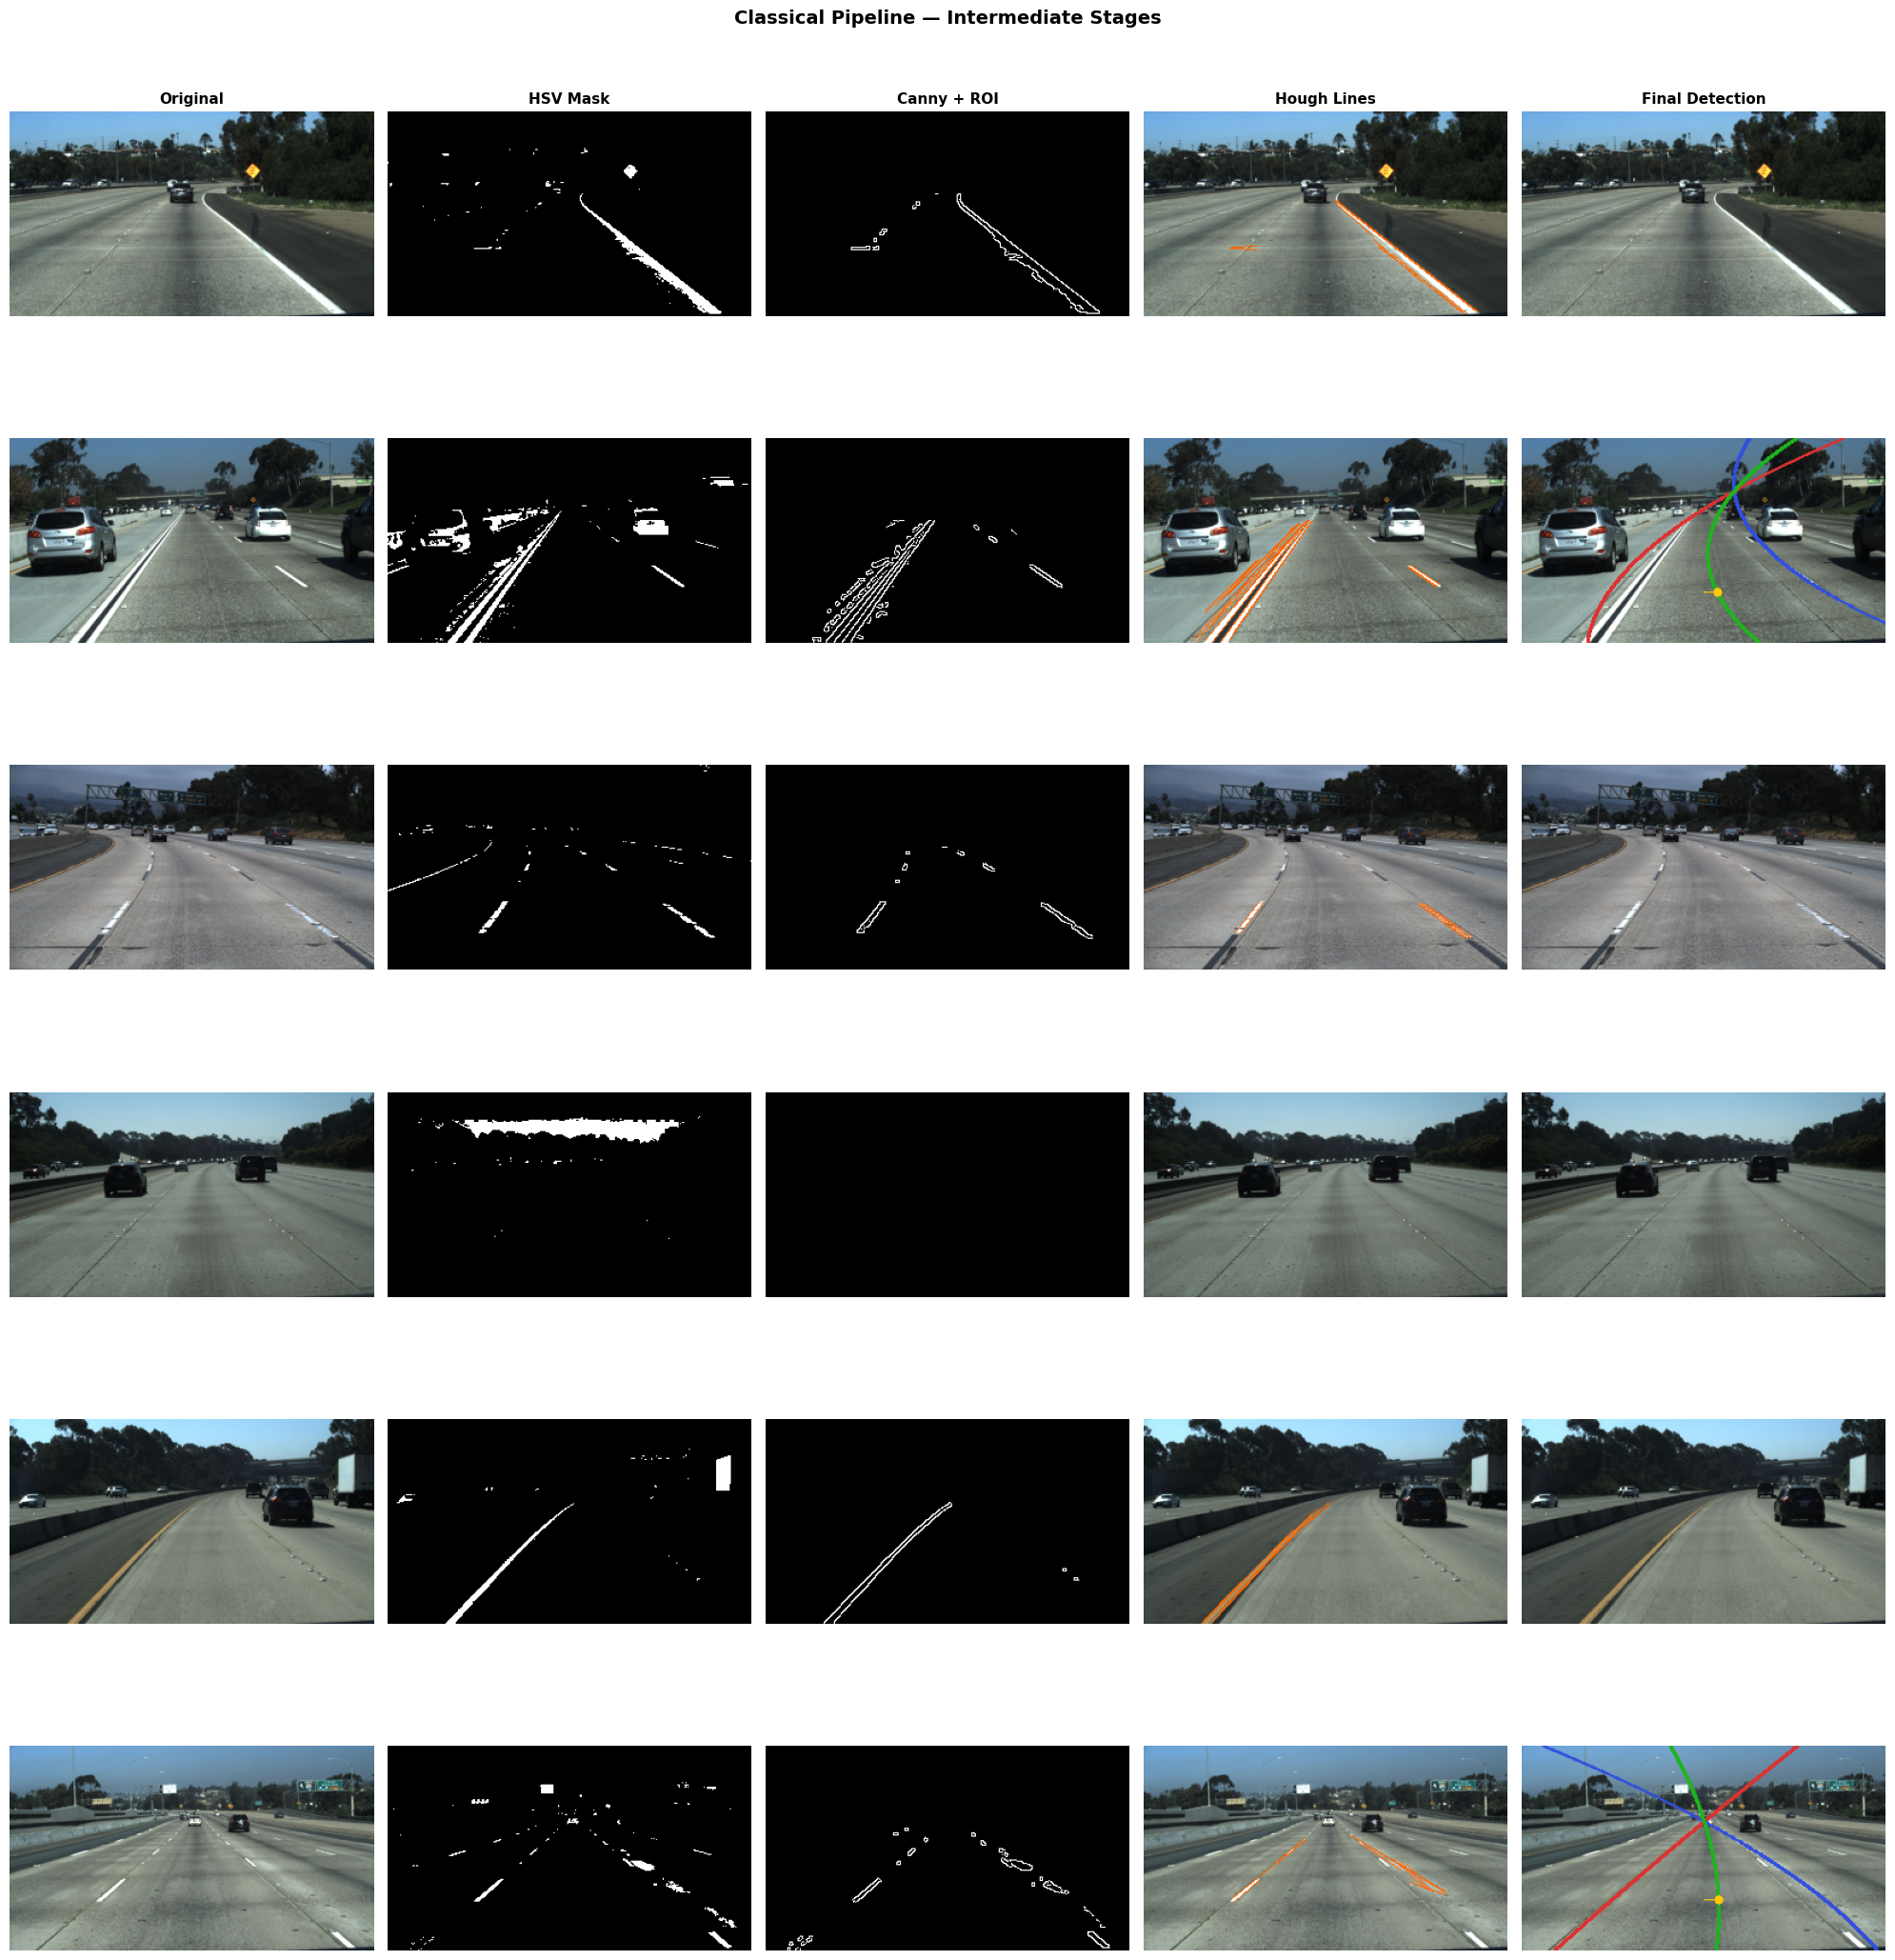

Saved: processed/classical_pipeline_stages.png


In [11]:
def draw_pipeline_result(img_bgr, result):
    """Draw detected lane polynomials on the image."""
    overlay = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
    if not result["has_lane"]:
        return overlay

    for coeffs, color in [(result["left_poly"], (220, 50, 50)),
                          (result["right_poly"], (50, 80, 220)),
                          (result["mid_poly"], (30, 180, 30))]:
        pts = []
        for y in range(IMG_H):
            x = int(round(poly_x(coeffs, y)))
            if 0 <= x < IMG_W:
                pts.append((x, y))
        for j in range(len(pts) - 1):
            cv2.line(overlay, pts[j], pts[j + 1], color, 2)

    # Steering indicator
    y_la = IMG_H - LOOKAHEAD_PX
    x_mid = int(round(poly_x(result["mid_poly"], y_la)))
    x_ctr = IMG_W // 2
    cv2.circle(overlay, (x_mid, y_la), 4, (255, 200, 0), -1)
    cv2.line(overlay, (x_ctr, y_la), (x_mid, y_la), (255, 200, 0), 1)
    return overlay


def draw_hough_on_image(img_bgr, lines):
    """Draw raw Hough line segments on image."""
    overlay = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
    if len(lines) == 0:
        return overlay
    for x1, y1, x2, y2 in lines:
        cv2.line(overlay, (int(x1), int(y1)), (int(x2), int(y2)),
                 (255, 100, 0), 1)
    return overlay


# Pick 6 lane samples from train
rng = random.Random(SEED)
vis_samples = rng.sample([l for l in train_labels if l["has_lane"]], 6)

fig, axes = plt.subplots(6, 5, figsize=(20, 22))
col_titles = ["Original", "HSV Mask", "Canny + ROI", "Hough Lines", "Final Detection"]

for row, label in enumerate(vis_samples):
    img = cv2.imread(label["image"])
    result = classical_pipeline(img)
    inter = result["intermediates"]

    # Col 0: original
    axes[row, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    # Col 1: HSV mask
    axes[row, 1].imshow(inter["hsv_mask"], cmap="gray")

    # Col 2: Canny + ROI
    axes[row, 2].imshow(inter["roi"], cmap="gray")

    # Col 3: Hough lines on image
    axes[row, 3].imshow(draw_hough_on_image(img, inter["hough_lines"]))

    # Col 4: Final polynomial overlay
    axes[row, 4].imshow(draw_pipeline_result(img, result))

    detected = "LANE" if result["has_lane"] else "NO LANE"
    err_str = f"err={result['steering_error']:.1f}" if result["steering_error"] else ""
    axes[row, 0].set_ylabel(f"{detected} {err_str}", fontsize=9, rotation=0,
                            labelpad=70, va="center")

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight="bold")

for ax in axes.flat:
    ax.axis("off")

plt.suptitle("Classical Pipeline — Intermediate Stages", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "classical_pipeline_stages.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved: processed/classical_pipeline_stages.png")

---\n## Cell 5 — Classical pipeline detection + HOG+SVM training\n\nTuSimple is a curated lane dataset: **every image has lanes** (`has_lane=True` for\nall 3 626 samples). There are no negative examples in the ground truth.\n\nTo still demonstrate the HOG+SVM classifier, we:\n1. Run the classical pipeline on all training images to get its `has_lane` predictions.\n2. Use the pipeline's **detection failures** as pseudo-negatives (label=0) and\n   successes as positives (label=1).\n3. Train the SVM to predict whether the pipeline will successfully detect lanes\n   from HOG features alone -- a useful meta-classifier for the deployment stage.\n\nWe also report the pipeline's **detection rate** (% of GT lane images where\nit successfully finds both lanes) as the primary classification metric.

In [12]:
# ── HOG parameters ────────────────────────────────────────────
ROI_Y_START = int(IMG_H * 0.40)  # row 72
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_ORIENTATIONS = 9


def extract_hog(img_bgr):
    """Extract HOG features from the ROI (lower 60%) of a BGR image."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    roi = gray[ROI_Y_START:, :]
    features = hog(roi,
                   orientations=HOG_ORIENTATIONS,
                   pixels_per_cell=HOG_PIXELS_PER_CELL,
                   cells_per_block=HOG_CELLS_PER_BLOCK,
                   feature_vector=True)
    return features


# ── Single pass: pipeline + HOG on training set ───────────────
# Load each image once, run both pipeline and HOG extraction together.
print("Running pipeline + HOG extraction on training set (single pass)...")
train_pipeline_results = []
X_train = []
y_train = []  # 1 = pipeline detected, 0 = pipeline failed

for label in tqdm(train_labels, desc="Train pipeline+HOG"):
    img = cv2.imread(label["image"])
    if img is None:
        train_pipeline_results.append({"has_lane": False})
        continue
    result = classical_pipeline(img)
    train_pipeline_results.append(result)
    X_train.append(extract_hog(img))
    y_train.append(1 if result["has_lane"] else 0)

X_train = np.array(X_train)
y_train = np.array(y_train)

n_detected = int(y_train.sum())
n_failed = len(y_train) - n_detected
det_rate = n_detected / len(y_train) * 100
print(f"\nPipeline detection rate (train): {n_detected}/{len(y_train)} = {det_rate:.1f}%")
print(f"  Detected: {n_detected}  |  Failed: {n_failed}")
print(f"HOG features: {X_train.shape}")

# ── Train SVM (only if both classes exist) ────────────────────
n_classes = len(set(y_train))
if n_classes >= 2:
    print(f"\nTraining LinearSVC ({n_classes} classes)...")
    svm = LinearSVC(C=1.0, max_iter=5000, random_state=SEED)
    svm.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, svm.predict(X_train))
    print(f"SVM train accuracy: {train_acc:.4f}")
    svm_trained = True
else:
    print(f"\nSVM skipped: only 1 class in training labels (pipeline detected all).")
    svm_trained = False

Running pipeline + HOG extraction on training set (single pass)...


Train pipeline+HOG: 100%|██████████| 2538/2538 [01:07<00:00, 37.70it/s]



Pipeline detection rate (train): 635/2538 = 25.0%
  Detected: 635  |  Failed: 1903
HOG features: (2538, 16848)

Training LinearSVC (2 classes)...
SVM train accuracy: 1.0000


---\n## Cell 6 — Test set evaluation\n\nMetrics reported:\n- **Pipeline detection rate:** % of GT lane images where the pipeline finds both lanes\n- **HOG+SVM metrics** (if trained): accuracy, precision, recall, F1, confusion matrix\n- **Polynomial RMSE:** per-point x-error between predicted and GT polynomials\n- **Steering error MAE:** |predicted - GT| at the lookahead row

Running pipeline + HOG extraction on test set (single pass)...


Test pipeline+HOG: 100%|██████████| 545/545 [00:24<00:00, 22.00it/s]



  Pipeline Detection Rate (Test Set)
  117/545 = 21.5%
  (All GT labels are has_lane=True in TuSimple)

  HOG+SVM Classification (Test Set)
  (predicting pipeline detection success)
  Accuracy:  0.7945
  Precision: 0.5203
  Recall:    0.5470
  F1 Score:  0.5333


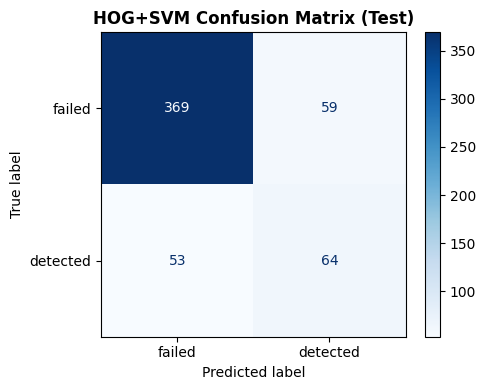


Computing regression metrics on detected samples...

  Regression Metrics (on 117 detected samples)
  Polynomial RMSE:    mean=75.62 px  median=20.80 px
  Steering Error MAE: mean=40.81 px  median=7.26 px

  CLASSICAL PIPELINE -- RESULTS SUMMARY
  Metric                              Value
  -----------------------------------------
  Detection Rate                      21.5%
  SVM Accuracy                       0.7945
  SVM Precision                      0.5203
  SVM Recall                         0.5470
  SVM F1                             0.5333
  Poly RMSE (px)                      75.62
  Steering MAE (px)                   40.81


In [13]:
# ── Single pass: pipeline + HOG on test set ───────────────────
print("Running pipeline + HOG extraction on test set (single pass)...")
test_pipeline_results = []
X_test = []
y_test_pipeline = []

for label in tqdm(test_labels, desc="Test pipeline+HOG"):
    img = cv2.imread(label["image"])
    if img is None:
        test_pipeline_results.append({"has_lane": False})
        continue
    result = classical_pipeline(img)
    test_pipeline_results.append(result)
    X_test.append(extract_hog(img))
    y_test_pipeline.append(1 if result["has_lane"] else 0)

X_test = np.array(X_test)
y_test_pipeline = np.array(y_test_pipeline)

n_test_detected = int(y_test_pipeline.sum())
n_test_total = len(y_test_pipeline)
test_det_rate = n_test_detected / n_test_total * 100

print(f"\n{'='*50}")
print(f"  Pipeline Detection Rate (Test Set)")
print(f"{'='*50}")
print(f"  {n_test_detected}/{n_test_total} = {test_det_rate:.1f}%")
print(f"  (All GT labels are has_lane=True in TuSimple)")

# ── HOG + SVM evaluation (if trained) ─────────────────────────
if svm_trained:
    y_test_svm = svm.predict(X_test)

    acc  = accuracy_score(y_test_pipeline, y_test_svm)
    prec = precision_score(y_test_pipeline, y_test_svm, zero_division=0)
    rec  = recall_score(y_test_pipeline, y_test_svm, zero_division=0)
    f1   = f1_score(y_test_pipeline, y_test_svm, zero_division=0)
    cm   = confusion_matrix(y_test_pipeline, y_test_svm)

    print(f"\n{'='*50}")
    print(f"  HOG+SVM Classification (Test Set)")
    print(f"  (predicting pipeline detection success)")
    print(f"{'='*50}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")

    fig, ax = plt.subplots(figsize=(5, 4))
    disp_labels = ["failed", "detected"]
    ConfusionMatrixDisplay(cm, display_labels=disp_labels).plot(ax=ax, cmap="Blues")
    ax.set_title("HOG+SVM Confusion Matrix (Test)", fontweight="bold")
    plt.tight_layout()
    plt.savefig(str(PROCESSED_DIR / "classical_confusion_matrix.png"),
                dpi=120, bbox_inches="tight")
    plt.show()
else:
    acc = test_det_rate / 100.0
    prec = rec = f1 = acc
    print("\nSVM was not trained (single class). Using pipeline detection rate as accuracy.")

# ── Polynomial RMSE + Steering MAE ────────────────────────────
print("\nComputing regression metrics on detected samples...")
poly_errors = []
steer_errors_abs = []

for label, result in zip(test_labels, test_pipeline_results):
    if not label["has_lane"] or not result["has_lane"]:
        continue

    gt_left = label["left_poly"]
    gt_right = label["right_poly"]
    pred_left = result["left_poly"]
    pred_right = result["right_poly"]

    ys = np.linspace(ROI_Y_START, IMG_H - 1, 30)
    sq_errs = []
    for y in ys:
        sq_errs.append((poly_x(pred_left, y) - poly_x(gt_left, y)) ** 2)
        sq_errs.append((poly_x(pred_right, y) - poly_x(gt_right, y)) ** 2)
    poly_errors.append(np.sqrt(np.mean(sq_errs)))

    steer_errors_abs.append(abs(result["steering_error"] - label["steering_error"]))

poly_errors = np.array(poly_errors)
steer_errors_abs = np.array(steer_errors_abs)

print(f"\n{'='*50}")
print(f"  Regression Metrics (on {len(poly_errors)} detected samples)")
print(f"{'='*50}")
print(f"  Polynomial RMSE:    mean={poly_errors.mean():.2f} px  "
      f"median={np.median(poly_errors):.2f} px")
print(f"  Steering Error MAE: mean={steer_errors_abs.mean():.2f} px  "
      f"median={np.median(steer_errors_abs):.2f} px")

# ── Summary table ─────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  CLASSICAL PIPELINE -- RESULTS SUMMARY")
print(f"{'='*55}")
print(f"  {'Metric':<30s} {'Value':>10s}")
print(f"  {'-'*41}")
print(f"  {'Detection Rate':<30s} {test_det_rate:>9.1f}%")
if svm_trained:
    print(f"  {'SVM Accuracy':<30s} {acc:>10.4f}")
    print(f"  {'SVM Precision':<30s} {prec:>10.4f}")
    print(f"  {'SVM Recall':<30s} {rec:>10.4f}")
    print(f"  {'SVM F1':<30s} {f1:>10.4f}")
print(f"  {'Poly RMSE (px)':<30s} {poly_errors.mean():>10.2f}")
print(f"  {'Steering MAE (px)':<30s} {steer_errors_abs.mean():>10.2f}")

---\n## Cell 7 — Test predictions visualisation\n\nShow 8 test samples: predicted lanes (dashed) vs ground truth lanes (solid).\nIncludes both correct detections and failure cases.

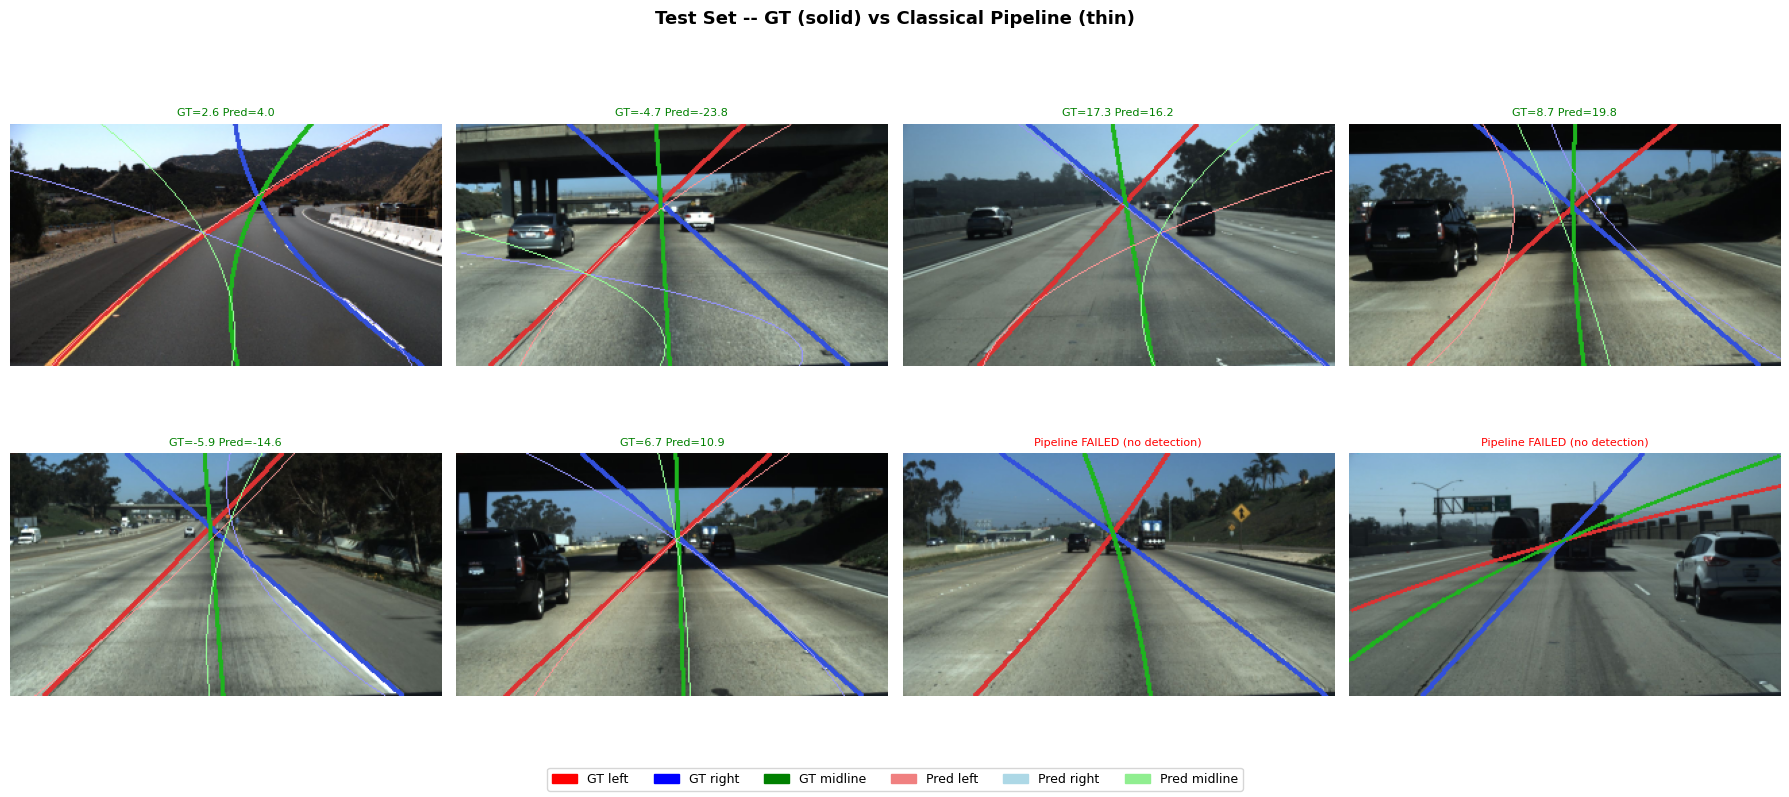

Saved: processed/classical_test_predictions.png
  Showing 6 detected + 2 failed samples

Notebook 02 complete. Next: 03_custom_cnn.ipynb


In [14]:
def draw_gt_vs_pred(img_bgr, gt_label, pred_result):
    """Overlay GT lanes (solid) and predicted lanes (thin) on image."""
    overlay = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()

    def draw_poly_line(coeffs, color, thickness=2):
        pts = []
        for y in range(IMG_H):
            x = int(round(poly_x(coeffs, y)))
            if 0 <= x < IMG_W:
                pts.append((x, y))
        for j in range(len(pts) - 1):
            cv2.line(overlay, pts[j], pts[j + 1], color, thickness)

    if gt_label["has_lane"]:
        draw_poly_line(gt_label["left_poly"], (220, 50, 50), 2)
        draw_poly_line(gt_label["right_poly"], (50, 80, 220), 2)
        draw_poly_line(gt_label["mid_poly"], (30, 180, 30), 2)

    if pred_result["has_lane"]:
        draw_poly_line(pred_result["left_poly"], (255, 150, 150), 1)
        draw_poly_line(pred_result["right_poly"], (150, 150, 255), 1)
        draw_poly_line(pred_result["mid_poly"], (150, 255, 150), 1)

    return overlay


# Pair labels with pipeline results, split by detection success
paired = list(zip(test_labels, test_pipeline_results))
detected = [(l, r) for l, r in paired if r["has_lane"]]
failed = [(l, r) for l, r in paired if not r["has_lane"]]

rng = random.Random(SEED + 1)
# Show some detected + some failed (if any exist)
n_det_show = min(6, len(detected))
n_fail_show = min(2, len(failed))
vis_pairs = rng.sample(detected, n_det_show)
if n_fail_show > 0:
    vis_pairs += rng.sample(failed, n_fail_show)

n_cols = 4
n_rows = (len(vis_pairs) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
fig.suptitle("Test Set -- GT (solid) vs Classical Pipeline (thin)",
             fontsize=13, fontweight="bold")

for idx, (label, result) in enumerate(vis_pairs):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col]
    img = cv2.imread(label["image"])
    if img is None:
        ax.set_title("MISSING", color="red", fontsize=9)
        ax.axis("off")
        continue

    overlay = draw_gt_vs_pred(img, label, result)
    ax.imshow(overlay)

    if result["has_lane"]:
        gt_err = label["steering_error"]
        pr_err = result["steering_error"]
        title = f"GT={gt_err:.1f} Pred={pr_err:.1f}"
        color = "green"
    else:
        title = "Pipeline FAILED (no detection)"
        color = "red"

    ax.set_title(title, fontsize=8, color=color)
    ax.axis("off")

for idx in range(len(vis_pairs), n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row, col].axis("off")

patches = [
    mpatches.Patch(color="red",        label="GT left"),
    mpatches.Patch(color="blue",       label="GT right"),
    mpatches.Patch(color="green",      label="GT midline"),
    mpatches.Patch(color="lightcoral", label="Pred left"),
    mpatches.Patch(color="lightblue",  label="Pred right"),
    mpatches.Patch(color="lightgreen", label="Pred midline"),
]
fig.legend(handles=patches, loc="lower center", ncol=6, fontsize=9)
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "classical_test_predictions.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: processed/classical_test_predictions.png")
print(f"  Showing {n_det_show} detected + {n_fail_show} failed samples")
print(f"\nNotebook 02 complete. Next: 03_custom_cnn.ipynb")